# MCMC Physical Validation
---
Reconstructs the physical quantities, $\tau$ and the ionization history, from
the cached MCMC chain by interpolating over the 1,000 simulation design points.

Produces three figures:
1. Tau Posterior (LinearND and IDW)
2. Ionization History Posterior (LinearND)
3. Ionization History Posterior (IDW)

More information about the package can be found here: [Documentation](https://robertxpearce.github.io/reionization-emulator/)

## Imports

In [1]:
import sys
import json

import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import LinearNDInterpolator
from scipy.spatial import cKDTree

## Paths, Configs, and Constants

In [2]:
# Paths
from config import H5_PATH, FIG_DIR, EXPERIMENT_NAME, MCMC_SINGLE_PATH, RECORDS_DIR, make_dirs

# Constants
from config import SEED, PARAM_BOUNDS, param_order

make_dirs()

## Seeding

In [3]:
np.random.seed(SEED)

print(f"Python:\t\t{sys.version.split()[0]}")
print("-" * 30)
print(f"NumPy:\t\t{np.__version__}")
print("-" * 30)
print(f"Global Seed:\t{SEED}")

Python:		3.13.1
------------------------------
NumPy:		2.4.3
------------------------------
Global Seed:	42


## Load Cached Chain

In [4]:
cached = np.load(MCMC_SINGLE_PATH)

samples = cached["samples"]
true_params = cached["true_params"]
observed_dl = cached["observed_dl"]
sigma_obs = cached["sigma_obs"]
TEST_SET_IDX = int(cached["test_set_idx"])

print(f"Chain: {MCMC_SINGLE_PATH.name}")
print(f"Posterior Samples: {samples.shape}")
print(f"discard={int(cached['discard'])}, thin={int(cached['thin'])}")

Chain: mcmc_single.npz
Posterior Samples: (17120, 4)
discard=559, thin=55


## Held-Out Mock Observation
- True Parameters: The _zreion_ parameters MCMC was trying to recover
- Observed $D_\ell$: The 5 binned kSZ rescaled angular power spectrum that is the "observed" data
- Sigma OBS: The assumed measurement uncertainty

In [5]:
print(f"TEST_SET_IDX:\t {TEST_SET_IDX}")
print(f"True Parameters: {true_params}")
print(f"Observed D_ell:\t {observed_dl}")
print(f"Sigma OBS:\t\t {sigma_obs}")

TEST_SET_IDX:	 37
True Parameters: [7.7922134  0.47120032 1.299202   0.47073376]
Observed D_ell:	 [1.391342   1.2893534  0.9857267  0.8343168  0.83325124]
Sigma OBS:		 [0.13913421 0.12893534 0.09857267 0.08343168 0.08332513]


## Parameter Recovery Table

In [6]:
header = f"{'Parameter':<12}{'True':>12}{'Post. Mean':>14}{'Post. Median (16/84)':>28}{'Mean - True':>14}"
print(header)
print("-" * len(header))
for i, label in enumerate(param_order):
    q16, q50, q84 = np.percentile(samples[:, i], [16, 50, 84])
    mean_i = samples[:, i].mean()
    true_i = true_params[i]
    median_str = f"{q50:.3f} +{q84 - q50:.3f} -{q50 - q16:.3f}"
    print(f"{label:<12}{true_i:>12.3f}{mean_i:>14.3f}{median_str:>28}{mean_i - true_i:>14.3f}")

Parameter           True    Post. Mean        Post. Median (16/84)   Mean - True
--------------------------------------------------------------------------------
zmean_zre          7.792         7.844         7.776 +0.737 -0.555         0.052
alpha_zre          0.471         0.423         0.392 +0.279 -0.197        -0.048
kb_zre             1.299         1.173         1.209 +0.549 -0.641        -0.126
b0_zre             0.471         0.496         0.487 +0.095 -0.076         0.025


## Interpolation Utilities

In [7]:
def normalize_params(X):
    """
    Min-max scaling: u = (x-lo)/(hi-lo)
    """
    X = np.asarray(X)
    return (X - PARAM_BOUNDS[:, 0]) / (PARAM_BOUNDS[:, 1] - PARAM_BOUNDS[:, 0])


def idw_predict(X_train, y_train, X_query, k=32, power=2, eps=1e-12):
    """
    Inverse distance weighting (Shepards method).
    X_train: (N, D)
    y_train: (N,) or (N, M)
    X_query: (Q, D)
    """
    # Build a k-d tree for fast nearest-neighbor lookup
    tree = cKDTree(X_train)
    # Find k nearest training points
    distances, indices = tree.query(X_query, k=k)

    # SciPy returns (Q,) when k=1; restore 2D shape (Q, 1)
    if k == 1:
        distances = distances[:, None]
        indices = indices[:, None]

    # Inverse-distance weights, normalized to sum to 1 per query
    weights = 1.0 / (distances + eps) ** power
    weights = weights / weights.sum(axis=1, keepdims=True)

    y_neighbors = y_train[indices]

    if y_train.ndim == 1:
        return np.sum(weights * y_neighbors, axis=1)

    return np.sum(weights[:, :, None] * y_neighbors, axis=1)

## Build Lookup Table

In [8]:
X_rows = []
tau_rows = []
xe_rows = []
z_grid = None

with h5py.File(H5_PATH, "r") as h5f:
    sims = h5f["sims"]

    sim_names = sorted(
        sims.keys(),
        key=lambda s: int(s[3:]) if s.startswith("sim") and s[3:].isdigit() else s,
    )

    for sim in sim_names:
        g = sims[sim]

        theta = [
            float(g[f"params/{p}"][()])
            for p in param_order
        ]

        # Tau
        tau = float(g["output/tau"][()])

        # Ionization history
        z_sim = np.array(g["output/zval_list"][()], dtype=float)
        xe = np.array(g["output/xmval_list"][()], dtype=float)

        z_order = np.argsort(z_sim)
        z_sim = z_sim[z_order]
        xe = xe[z_order]

        if z_grid is None:
            z_grid = z_sim
        else:
            if len(z_sim) != len(z_grid) or not np.allclose(z_sim, z_grid):
                xe = np.interp(z_grid, z_sim, xe)

        X_rows.append(theta)
        tau_rows.append(tau)
        xe_rows.append(xe)

X_sim = np.array(X_rows, dtype=float)
tau_sim = np.array(tau_rows, dtype=float)
xe_sim = np.array(xe_rows, dtype=float)

print("X_sim shape:\t", X_sim.shape)
print("tau_sim shape:\t", tau_sim.shape)
print("xe_sim shape:\t", xe_sim.shape)
print("z_grid shape:\t", z_grid.shape)

assert X_sim.shape[1] == 4
assert tau_sim.shape[0] == X_sim.shape[0]
assert xe_sim.shape[0] == X_sim.shape[0]
assert xe_sim.shape[1] == len(z_grid)

X_sim shape:	 (1000, 4)
tau_sim shape:	 (1000,)
xe_sim shape:	 (1000, 26)
z_grid shape:	 (26,)


## Normalize

In [9]:
# Normalize full simulation design points
Xn = normalize_params(X_sim)

# Normalize MCMC posterior samples
samples_n = normalize_params(samples)

# Normalize true parameters
true_n = normalize_params(true_params[None, :])

# Posterior summary parameters
posterior_mean = samples.mean(axis=0)
posterior_median = np.median(samples, axis=0)

posterior_p16 = np.percentile(samples, 16, axis=0)
posterior_p84 = np.percentile(samples, 84, axis=0)

# Normalize posterior mean and median
posterior_mean_n = normalize_params(posterior_mean[None, :])
posterior_median_n = normalize_params(posterior_median[None, :])

print("Posterior mean:\t ", posterior_mean)
print("Posterior median:", posterior_median)
print("Posterior 16th percentile:", posterior_p16)
print("Posterior 84th percentile:", posterior_p84)

Posterior mean:	  [7.84448002 0.42342375 1.17333755 0.49576141]
Posterior median: [7.77563021 0.39157905 1.20868315 0.48667738]
Posterior 16th percentile: [7.2204882  0.19456834 0.56718765 0.41060729]
Posterior 84th percentile: [8.51289745 0.67071697 1.75806535 0.58179803]


# Optical Depth ($\tau$) Recovery
---
Tau is recovered by interpolating the 1,000 simulations' $\tau$ values onto the MCMC posterior samples. Both interpolatoes are applied to the same samples.
- **LinearND**
    - Piecewise-linear interpolation of $\tau$ over a Delaunay triangulation of the normalized design points; exact at the design points themselves.
    - Returns NaN for posterior samples outside the convex hull of the simulations. The printed NaN fraction measures how much of the $\tau$ posterior is excluded because it would require extrapolation.
    - Provides the reported $\tau$ posterior: the credible intervals, summary statistics, percent error, and figures all use it.
- **IDW**
    - Inverse-distance-weighted $\tau$ from the $k = 32$ nearest simulations; defined for every posterior sample, including those outside the convex hull.
    - Serves as the cross-check. Agreement with LinearND shows the $\tau$ posterior is insensitive to the choice of interpolation method, and covering the out-of-hull samples shows they do not shift the result.

## Method 1: LinearNDInterpolator for Tau

In [10]:
tau_linear_interp = LinearNDInterpolator(Xn, tau_sim, fill_value=np.nan)

tau_true_interp = tau_linear_interp(true_n)[0]
tau_mean_interp = tau_linear_interp(posterior_mean_n)[0]
tau_posterior_linear = tau_linear_interp(samples_n)

print("LinearND Tau at True Params:\t", tau_true_interp)
print("LinearND Tau at Posterior Mean:\t", tau_mean_interp)

nan_frac = np.isnan(tau_posterior_linear).mean()
print(f"\nPosterior Samples Outside Convex Hull (LinearND NaN): {nan_frac * 100:.2f}% ({np.isnan(tau_posterior_linear).sum()} / {len(tau_posterior_linear)})")

LinearND Tau at True Params:	 0.058188996588756474
LinearND Tau at Posterior Mean:	 0.058891292787353

Posterior Samples Outside Convex Hull (LinearND NaN): 9.39% (1608 / 17120)


## Method 2: IDW for Tau

In [11]:
tau_true_idw = idw_predict(Xn, tau_sim, true_n)[0]
tau_mean_idw = idw_predict(Xn, tau_sim, posterior_mean_n)[0]
tau_posterior_idw = idw_predict(Xn, tau_sim, samples_n)

print("IDW Tau at True Params:\t\t", tau_true_idw)
print("IDW Tau at Posterior Mean:\t", tau_mean_idw)

IDW Tau at True Params:		 0.058188995270356994
IDW Tau at Posterior Mean:	 0.05857194270271973


## Summary Function

In [12]:
def summarize(values):
    values = np.asarray(values)
    values = values[np.isfinite(values)]

    return {
        "mean": np.mean(values),
        "median": np.median(values),
        "p16": np.percentile(values, 16),
        "p84": np.percentile(values, 84),
        "p2.5": np.percentile(values, 2.5),
        "p97.5": np.percentile(values, 97.5),
    }


tau_summary = summarize(tau_posterior_linear)
print("Tau Posterior Summary (LinearND):")
for k, v in tau_summary.items():
    print(f"\t{k:<7} {v:.5f}")

tau_summary_idw = summarize(tau_posterior_idw)
print("\nTau Posterior Summary (IDW):")
for k, v in tau_summary_idw.items():
    print(f"\t{k:<7} {v:.5f}")

Tau Posterior Summary (LinearND):
	mean    0.05904
	median  0.05833
	p16     0.05362
	p84     0.06485
	p2.5    0.05198
	p97.5   0.06871

Tau Posterior Summary (IDW):
	mean    0.05905
	median  0.05814
	p16     0.05419
	p84     0.06480
	p2.5    0.05322
	p97.5   0.06741


## Tau Posterior

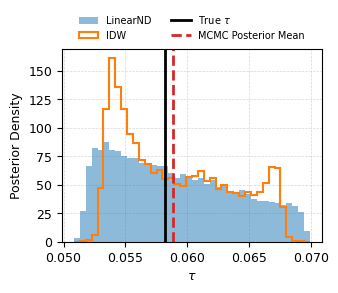

LinearND (primary)
	True Tau					 = 0.0582
	Tau at Posterior-Mean Params = 0.0589
	Mean of Tau Posterior		 = 0.0590
	Posterior 68% Interval		 = [0.0536, 0.0649]
	Posterior 95% Interval		 = [0.0520, 0.0687]

	True Tau Inside 68% Interval: True
	True Tau Inside 95% Interval: True

IDW (cross-check)
	True Tau					 = 0.0582
	Tau at Posterior-Mean Params = 0.0586
	Posterior 68% Interval		 = [0.0542, 0.0648]


In [13]:
fig, ax = plt.subplots()

tau_linear_valid = tau_posterior_linear[np.isfinite(tau_posterior_linear)]

bin_edges = np.histogram_bin_edges(np.concatenate([tau_posterior_idw, tau_linear_valid]), bins=40)

ax.hist(tau_linear_valid, bins=bin_edges, alpha=0.5, density=True, color="tab:blue", label="LinearND")
ax.hist(tau_posterior_idw, bins=bin_edges, density=True, histtype="step", linewidth=1.5, color="tab:orange", label="IDW")

ax.axvline(tau_true_interp, linestyle="-", linewidth=2, color="black", label=r"True $\tau$")
ax.axvline(tau_mean_interp, linestyle="--", linewidth=2, color="tab:red", label=r"MCMC Posterior Mean")

ax.set_xlabel(r"$\tau$")
ax.set_ylabel("Posterior Density")

ax.set_axisbelow(True)
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
ax.legend(frameon=False, fontsize=7, ncol=2, loc="lower center", bbox_to_anchor=(0.5, 1.0))

fig.savefig(FIG_DIR / f"tau_posterior_{EXPERIMENT_NAME}.pdf", format="pdf", bbox_inches="tight")
plt.show()

tau_p16, tau_p84 = tau_summary["p16"], tau_summary["p84"]
tau_p025, tau_p975 = tau_summary["p2.5"], tau_summary["p97.5"]

in_68 = tau_p16 <= tau_true_interp <= tau_p84
in_95 = tau_p025 <= tau_true_interp <= tau_p975

print("LinearND (primary)")
print(f"\tTrue Tau\t\t\t\t\t = {tau_true_interp:.4f}")
print(f"\tTau at Posterior-Mean Params = {tau_mean_interp:.4f}")
print(f"\tMean of Tau Posterior\t\t = {tau_summary['mean']:.4f}")
print(f"\tPosterior 68% Interval\t\t = [{tau_p16:.4f}, {tau_p84:.4f}]")
print(f"\tPosterior 95% Interval\t\t = [{tau_p025:.4f}, {tau_p975:.4f}]")
print()
print(f"\tTrue Tau Inside 68% Interval: {in_68}")
print(f"\tTrue Tau Inside 95% Interval: {in_95}")

print("\nIDW (cross-check)")
print(f"\tTrue Tau\t\t\t\t\t = {tau_true_idw:.4f}")
print(f"\tTau at Posterior-Mean Params = {tau_mean_idw:.4f}")
print(f"\tPosterior 68% Interval\t\t = [{tau_summary_idw['p16']:.4f}, {tau_summary_idw['p84']:.4f}]")

# Ionization History Recovery
---
The ionization history is recovered by interpolating the 1,000 simulations' 26 mean ionized fraction at every redshift value onto the MCMC posterior samples. Both interpolators are applied to the same samples.
- **LinearND**
    - Piecewise-linear interpolation of ionization history over a Delaunay triangulation of the normalized design points; exact at the design points themselves.
    - Returns NaN for posterior samples outside the convex hull of the simulations - the printed NaN fraction measures how much of the ionization history posterior is excluded because it would require extrapolation.
    - Provides the reported ionization history: the credible bands, percent error, and figures all use it.
- **IDW**
    - Inverse-distance-weighted ionization history from the $k = 32$ nearest simulations; defined for every posterior sample, including those outside the convex hull.
    - Serves as the cross-check. Agreement with LinearND shows the recovered history is insensitive to the choice of interpolation method, and covering the out-of-hull samples shows they do not shift the result.

## Method 1: LinearNDInterpolator for Ionization History

In [14]:
ionization_history_linear_interp = LinearNDInterpolator(Xn, xe_sim, fill_value=np.nan)

ionization_history_true_interp = ionization_history_linear_interp(true_n)[0]
ionization_history_mean_interp = ionization_history_linear_interp(posterior_mean_n)[0]
ionization_history_posterior_linear = ionization_history_linear_interp(samples_n)

print("LinearND Ionization History at True Params:", ionization_history_true_interp)
print("LinearND Ionization History at Posterior Mean:", ionization_history_mean_interp)

outside_hull = np.isnan(ionization_history_posterior_linear).any(axis=1)
nan_frac = outside_hull.mean()
print(f"\nPosterior samples outside convex hull (LinearND NaN): "
      f"{nan_frac * 100:.2f}% ({outside_hull.sum()} / {len(outside_hull)})")

LinearND Ionization History at True Params: [5.10770581e-09 3.08650771e-05 2.91330047e-03 3.75562610e-02
 1.56838623e-01 3.48855914e-01 5.48599948e-01 7.10247492e-01
 8.23147821e-01 8.95397939e-01 9.39253408e-01 9.65051485e-01
 9.79964959e-01 9.88510223e-01 9.93384424e-01 9.96176634e-01
 9.97775843e-01 9.98697499e-01 9.99230409e-01 9.99541939e-01
 9.99725785e-01 9.99899642e-01 9.99962005e-01 9.99985433e-01
 9.99993883e-01 9.99997574e-01]
LinearND Ionization History at Posterior Mean: [1.44643669e-05 3.15925116e-04 5.01839834e-03 4.21808827e-02
 1.56554380e-01 3.36846361e-01 5.27178138e-01 6.85966954e-01
 8.01088121e-01 8.77758899e-01 9.26222407e-01 9.55906825e-01
 9.73755927e-01 9.84383281e-01 9.90682291e-01 9.94420558e-01
 9.96640080e-01 9.97963521e-01 9.98756876e-01 9.99235692e-01
 9.99527221e-01 9.99814957e-01 9.99924932e-01 9.99968907e-01
 9.99986504e-01 9.99994115e-01]

Posterior samples outside convex hull (LinearND NaN): 9.39% (1608 / 17120)


## Method 2: IDW for Ionization History

In [15]:
assert xe_sim.shape[0] == X_sim.shape[0]
assert xe_sim.shape[1] == len(z_grid)

xe_true_idw = idw_predict(Xn, xe_sim, true_n)[0]
xe_mean_idw = idw_predict(Xn, xe_sim, posterior_mean_n)[0]
xe_posterior_idw = idw_predict(Xn, xe_sim, samples_n)

xe_mean = np.mean(xe_posterior_idw, axis=0)
xe_p16 = np.percentile(xe_posterior_idw, 16, axis=0)
xe_p84 = np.percentile(xe_posterior_idw, 84, axis=0)
xe_p025 = np.percentile(xe_posterior_idw, 2.5, axis=0)
xe_p975 = np.percentile(xe_posterior_idw, 97.5, axis=0)

## Plot LinearNDInterpolator Ionization History

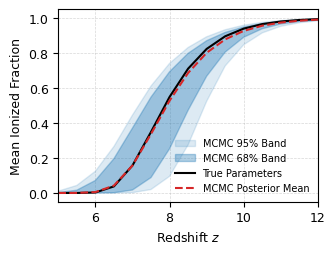

True within 68% band: 80.8% of 26 redshift bins
True within 95% band: 100.0% of 26 redshift bins


In [16]:
# LinearND posterior stats (NaN rows = out-of-hull samples are ignored by nan* funcs)
xe_lin_mean = np.nanmean(ionization_history_posterior_linear, axis=0)
xe_lin_p16  = np.nanpercentile(ionization_history_posterior_linear, 16,   axis=0)
xe_lin_p84  = np.nanpercentile(ionization_history_posterior_linear, 84,   axis=0)
xe_lin_p025 = np.nanpercentile(ionization_history_posterior_linear, 2.5,  axis=0)
xe_lin_p975 = np.nanpercentile(ionization_history_posterior_linear, 97.5, axis=0)

fig, ax = plt.subplots()

ax.fill_between(z_grid, xe_lin_p025, xe_lin_p975, color="tab:blue", alpha=0.15, label="MCMC 95% Band")
ax.fill_between(z_grid, xe_lin_p16, xe_lin_p84, color="tab:blue", alpha=0.35, label="MCMC 68% Band")

ax.plot(z_grid, ionization_history_true_interp, color="black", linewidth=1.5, label="True Parameters")
ax.plot(z_grid, ionization_history_mean_interp, "--", color="tab:red", linewidth=1.5, label="MCMC Posterior Mean")

ax.set_xlim(5, 12)
ax.set_xlabel("Redshift $z$")
ax.set_ylabel(r"Mean Ionized Fraction")

ax.set_axisbelow(True)
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
ax.legend(frameon=False, fontsize=7, loc="lower right")

fig.savefig(FIG_DIR / f"ionization_history_posterior_linear_{EXPERIMENT_NAME}.pdf", format="pdf", bbox_inches="tight")
plt.show()

inside_68 = (ionization_history_true_interp >= xe_lin_p16) & (ionization_history_true_interp <= xe_lin_p84)
inside_95 = (ionization_history_true_interp >= xe_lin_p025) & (ionization_history_true_interp <= xe_lin_p975)

frac_68 = inside_68.mean()
frac_95 = inside_95.mean()

print(f"True within 68% band: {frac_68 * 100:.1f}% of {len(z_grid)} redshift bins")
print(f"True within 95% band: {frac_95 * 100:.1f}% of {len(z_grid)} redshift bins")

## Plot IDW Ionization History

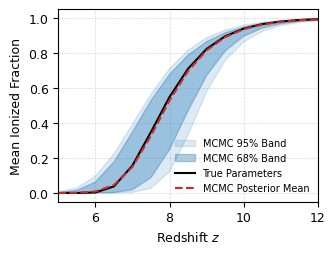

True within 68% band: 65.4% of 26 redshift bins
True within 95% band: 100.0% of 26 redshift bins


In [17]:
fig, ax = plt.subplots()

ax.fill_between(z_grid, xe_p025, xe_p975, color="tab:blue", alpha=0.15, label="MCMC 95% Band")
ax.fill_between(z_grid, xe_p16, xe_p84, color="tab:blue", alpha=0.35, label="MCMC 68% Band")

ax.plot(z_grid, xe_true_idw, color="black", linewidth=1.5, label="True Parameters")
ax.plot(z_grid, xe_mean_idw, "--", color="tab:red", linewidth=1.5, label="MCMC Posterior Mean")

ax.set_xlim(5, 12)
ax.set_xlabel("Redshift $z$")
ax.set_ylabel(r"Mean Ionized Fraction")

ax.set_axisbelow(True)
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
ax.legend(frameon=False, fontsize=7, loc="lower right")

fig.savefig(FIG_DIR / f"ionization_history_posterior_{EXPERIMENT_NAME}.pdf", format="pdf", bbox_inches="tight")
plt.show()

# Quantitative validation: does the true xm lie within the credible bands?
inside_68 = (xe_true_idw >= xe_p16) & (xe_true_idw <= xe_p84)
inside_95 = (xe_true_idw >= xe_p025) & (xe_true_idw <= xe_p975)

frac_68 = inside_68.mean()
frac_95 = inside_95.mean()

print(f"True within 68% band: {frac_68 * 100:.1f}% of {len(z_grid)} redshift bins")
print(f"True within 95% band: {frac_95 * 100:.1f}% of {len(z_grid)} redshift bins")

## Percent Error for Tau and Ionization History (Most Central Case)

In [18]:
# Tau: value at the posterior-mean parameters against the true value
tau_percent_error = 100.0 * abs(tau_mean_interp - tau_true_interp) / tau_true_interp

print("LinearND (primary)")
print(f"\tTau True:\t\t\t\t{tau_true_interp:.4f}")
print(f"\tTau at Posterior Mean:\t{tau_mean_interp:.4f}")
print(f"\tTau Percent Error:\t\t{tau_percent_error:.2f}%")

# Ionization history: mean fractional error where reionization is in progress.
xe_true = ionization_history_true_interp
xe_post = ionization_history_mean_interp
mask = (xe_true > 0.05) & (xe_true < 0.95)

xe_abs_error = np.mean(np.abs(xe_post[mask] - xe_true[mask]))
xe_percent_error = 100.0 * np.mean(np.abs(xe_post[mask] - xe_true[mask]) / xe_true[mask])

print(f"\n\tBins Used:\t\t\t\t{mask.sum()} of {len(z_grid)}")
print(f"\tRedshift Range:\t\t\tz = {z_grid[mask].min():.1f} to {z_grid[mask].max():.1f}")
print(f"\tMean Absolute Error:\t{xe_abs_error:.4f}")
print(f"\tMean Percent Error:\t\t{xe_percent_error:.2f}%")

# Cross-check
tau_percent_error_idw = 100.0 * abs(tau_mean_idw - tau_true_idw) / tau_true_idw
xe_abs_error_idw = np.mean(np.abs(xe_mean_idw[mask] - xe_true_idw[mask]))
xe_percent_error_idw = 100.0 * np.mean(np.abs(xe_mean_idw[mask] - xe_true_idw[mask]) / xe_true_idw[mask])

print("\nIDW (cross-check)")
print(f"\tTau Percent Error:\t\t{tau_percent_error_idw:.2f}%")
print(f"\tMean Absolute Error:\t{xe_abs_error_idw:.4f}")
print(f"\tMean Percent Error:\t\t{xe_percent_error_idw:.2f}%")

LinearND (primary)
	Tau True:				0.0582
	Tau at Posterior Mean:	0.0589
	Tau Percent Error:		1.21%

	Bins Used:				7 of 26
	Redshift Range:			z = 7.0 to 10.0
	Mean Absolute Error:	0.0158
	Mean Percent Error:		2.43%

IDW (cross-check)
	Tau Percent Error:		0.66%
	Mean Absolute Error:	0.0111
	Mean Percent Error:		2.61%


## Save Records

In [19]:
physical_validation = {
    "test_set_idx": TEST_SET_IDX,
    "true_params": [float(v) for v in true_params],
    "posterior_mean": [float(v) for v in posterior_mean],
    "posterior_median": [float(v) for v in posterior_median],
    # Primary: LinearND, plug-in at the posterior-mean parameters.
    "interpolator": "LinearNDInterpolator",
    "estimator": "plug-in at posterior-mean parameters",
    "tau_true": float(tau_true_interp),
    "tau_at_posterior_mean": float(tau_mean_interp),
    "tau_posterior": {k: float(v) for k, v in tau_summary.items()},
    "tau_percent_error": float(tau_percent_error),
    "xe_mean_absolute_error": float(xe_abs_error),
    "xe_mean_percent_error": float(xe_percent_error),
    "xe_bins_used": int(mask.sum()),
    "posterior_out_of_hull_fraction": float(nan_frac),
    # Cross-check: IDW over all samples.
    "cross_check_idw": {
        "tau_true": float(tau_true_idw),
        "tau_at_posterior_mean": float(tau_mean_idw),
        "tau_posterior": {k: float(v) for k, v in tau_summary_idw.items()},
        "tau_percent_error": float(tau_percent_error_idw),
        "xe_mean_absolute_error": float(xe_abs_error_idw),
        "xe_mean_percent_error": float(xe_percent_error_idw),
    },
}

path = RECORDS_DIR / "physical_validation.json"
with path.open("w", encoding="utf-8") as fh:
    json.dump(physical_validation, fh, indent=4, sort_keys=True)
    fh.write("\n")

print(f"Physical Validation:\n{path}")

Physical Validation:
/Users/robertxpearce/Desktop/Research/LEADS Lab/Reionization Emulator/Code/reionization-emulator/results/pearce_2026_reionemu_mc_dropout/n_mc_201_epochs_1000_early_stop_150/records/physical_validation.json
